# 07 — Variant Comparison (cross-pipeline, with HAR-RV and naive references)

Pure comparison notebook. **No training happens here** — all training is done upstream:

- nb 01 — data + feature engineering
- nb 02 — EDA + normality tests
- nb 03 — three HMM variants (O, A, B) + `p_volatile` injection
- nb 04 — four baseline LSTMs (O, A, H, B)
- nb 05 — three regime-LSTM pairs (O, A, B)
- nb 06 — per-variant ensemble + WITHIN-variant DM tests

This notebook is the **cross-variant** comparison. It loads every variant's predictions from `data/processed/test_predictions*.parquet`, generates HAR-RV predictions, and produces:

1. **6-way metrics table** — row-aligned on the common test-date index across all predictors.
2. **15 × 2 = 30 pairwise Diebold-Mariano tests** with **Bonferroni** + **Benjamini-Hochberg (FDR)** multiple-testing correction.
3. **F1 diagnostic** — cross-correlation peak lag per predictor (evidence that LSTMs are persistence-shifted predictors).
4. **F2 diagnostic** — prediction std per regime-LSTM (evidence that volatile-regime LSTMs collapse toward constant).
5. **Summary** with paper-quotable claims scaffolded to fill in from the tables.

## Predictors compared

| # | Name | Type | Source |
|---|---|---|---|
| 1 | **naive** | persistence | `rolling_std_21` from `test.parquet` |
| 2 | **HAR-RV** | econometric | `src/har_rv.py` (run next cell) |
| 3 | **variant O ensemble** | regime-split LSTM | `test_predictions_O.parquet` |
| 4 | **variant A ensemble** | regime-split LSTM | `test_predictions.parquet` |
| 5 | **variant H baseline** | single LSTM + `p_volatile` feature | `test_predictions_H.parquet` |
| 6 | **variant B ensemble** | regime-split LSTM + VIX features | `test_predictions_B.parquet` |

**Alignment:** all six predictors are intersected on a common test-date index. Variant B's window starts later (VIX3M history) and HAR-RV's starts earlier (shorter warmup), so the intersection gives the **strictly row-for-row comparable** subset.


In [1]:
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import config
from src.utils import regression_metrics

DATA_PROCESSED = config.DATA_PROCESSED
LOG_DIR = REPO_ROOT / "logs"
LOG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
print("Repo root:", REPO_ROOT)


Repo root: /content/repo


## 1. Prerequisite check

Confirms all per-variant prediction parquets exist (from nb 06). HAR-RV is generated in the next cell, so its parquet is not required yet.


In [2]:
REQUIRED_PREDICTIONS = {
    "variant O (ensemble)": DATA_PROCESSED / "test_predictions_O.parquet",
    "variant A (ensemble)": DATA_PROCESSED / "test_predictions.parquet",
    "variant H (baseline)": DATA_PROCESSED / "test_predictions_H.parquet",
    "variant B (ensemble)": DATA_PROCESSED / "test_predictions_B.parquet",
}
missing = {k: str(v) for k, v in REQUIRED_PREDICTIONS.items() if not v.exists()}
if missing:
    raise RuntimeError(
        "Missing per-variant prediction parquets:\n" +
        "\n".join(f"  {k}: {v}" for k, v in missing.items()) +
        "\n\nRun nb 06 first (ensemble invocations for O, A, B + variant-H predictions)."
    )
print(f"All {len(REQUIRED_PREDICTIONS)} per-variant prediction parquets present.")


All 4 per-variant prediction parquets present.


## 2. Generate HAR-RV predictions

Runs `python -m src.har_rv` to produce `test_predictions_harrv.parquet` (OLS of `realized_vol_21d` on backward 1/5/21-day RV components — see Corsi 2002/2004 and the 2026-04-24 entry in `supplementary/discussion.md` for target-formula alignment). Fast (~100 ms).


In [3]:
cmd = [sys.executable, "-u", "-m", "src.har_rv"]
log_path = LOG_DIR / "har_rv.log"
print(f"Running: {' '.join(cmd)}")
with open(log_path, "w") as f:
    result = subprocess.run(cmd, cwd=str(REPO_ROOT), stdout=f, stderr=subprocess.STDOUT)
if result.returncode != 0:
    print(f"  FAILED (rc={result.returncode}) — see {log_path}")
else:
    out_path = DATA_PROCESSED / "test_predictions_harrv.parquet"
    print(f"  ok → {out_path.name} (log: {log_path.name})")
    # Print last 30 lines of log (equivalent to !tail -30 in pure Python)
    log_tail = "\n".join(log_path.read_text().splitlines()[-30:])
    print(log_tail)


Running: /usr/bin/python3 -u -m src.har_rv


  ok → test_predictions_harrv.parquet (log: har_rv.log)
23:20:01 | INFO    | har_rv | Fit rows: 3690, Eval rows: 1461 (target=realized_vol_21d)

 HAR-RV — fitted OLS coefficients
  intercept : +2.722841e-03
  rv_d      : +4.602568e-02
  rv_w      : +2.337972e-01
  rv_m      : +4.935455e-01

── Test-set metrics ──
  naive    MSE=2.225590e-05  RMSE=0.004718  MAE=0.003177  MAPE=34.82%
  har_rv   MSE=1.641475e-05  RMSE=0.004052  MAE=0.002819  MAPE=31.45%

── Diebold-Mariano: HAR-RV vs Naive (rolling_std_21) ──
  Naive vs HAR-RV  [MSE]  DM=+1.76  p=0.079  *     tie
  Naive vs HAR-RV  [MAE]  DM=+2.69  p=0.007  ***   HAR-RV wins
23:20:01 | INFO    | har_rv | Saved HAR-RV predictions → /content/repo/data/processed/test_predictions_harrv.parquet


## 3. Load all predictions and align to common index

Each prediction parquet has its own natural test window (determined by LSTM `seq_len` for variants and the 21-day backward window for HAR-RV). The intersection of all five gives the row-for-row comparable index.


In [4]:
pred_A   = pd.read_parquet(DATA_PROCESSED / "test_predictions.parquet")
pred_B   = pd.read_parquet(DATA_PROCESSED / "test_predictions_B.parquet")
pred_H   = pd.read_parquet(DATA_PROCESSED / "test_predictions_H.parquet")
pred_O   = pd.read_parquet(DATA_PROCESSED / "test_predictions_O.parquet")
pred_HAR = pd.read_parquet(DATA_PROCESSED / "test_predictions_harrv.parquet")

# Native row counts (before intersection)
print("Native row counts per predictor:")
for name, df in [("A", pred_A), ("B", pred_B), ("H", pred_H), ("O", pred_O), ("HAR-RV", pred_HAR)]:
    print(f"  {name}: {len(df):>5}  ({df.index.min().date()} → {df.index.max().date()})")

# Intersection — all five must overlap
common = (
    pred_A.index
    .intersection(pred_B.index)
    .intersection(pred_H.index)
    .intersection(pred_O.index)
    .intersection(pred_HAR.index)
)
print(f"\nCommon test-date index: {len(common)} rows  ({common.min().date()} → {common.max().date()})")

pred_A   = pred_A.loc[common]
pred_B   = pred_B.loc[common]
pred_H   = pred_H.loc[common]
pred_O   = pred_O.loc[common]
pred_HAR = pred_HAR.loc[common]

y_true = pred_A["target"].values  # same target across all predictors (variant A's parquet is fine)

# Naive: load test_df and align rolling_std_21 on the common index.
#
# ddof convention: `rolling_std_21` in the parquets uses pandas' default
# sample std (ddof=1, divisor m-1), while our target `realized_vol_21d`
# uses the population form (1/m demeaned, Andersen-Bollerslev 1998).
# This introduces a systematic ~2.5% upward bias in naive vs the "true
# target shifted 21 days earlier" identity. The bias is consistent across
# every DM comparison against naive, so rankings are preserved — but
# paper should disclose this in limitations.
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")
naive = test_df["rolling_std_21"].reindex(common).values

# Sanity: target consistency across parquets
for name, df in [("A", pred_A), ("B", pred_B), ("H", pred_H), ("O", pred_O), ("HAR-RV", pred_HAR)]:
    max_diff = np.abs(df["target"].values - y_true).max()
    assert max_diff < 1e-10, f"Target mismatch in variant {name}: max |diff| = {max_diff}"
print("Target consistency check: OK (all predictors share identical y_true on common index).")


Native row counts per predictor:
  A:  1440  (2020-06-30 → 2026-03-24)
  B:  1440  (2020-06-30 → 2026-03-24)
  H:  1461  (2020-06-01 → 2026-03-24)
  O:  1440  (2020-06-30 → 2026-03-24)
  HAR-RV:  1461  (2020-06-01 → 2026-03-24)

Common test-date index: 1440 rows  (2020-06-30 → 2026-03-24)
Target consistency check: OK (all predictors share identical y_true on common index).


## 4. 6-way headline metric table

MSE / RMSE / MAE / MAPE for every predictor on the common index. The "best" predictor per metric is highlighted for the paper.


In [5]:
predictors = {
    "naive":                 naive,
    "HAR-RV":                pred_HAR["har_rv"].values,
    "variant O (ensemble)":  pred_O["ensemble"].values,
    "variant A (ensemble)":  pred_A["ensemble"].values,
    "variant H (baseline)":  pred_H["baseline"].values,
    "variant B (ensemble)":  pred_B["ensemble"].values,
}

rows = []
for name, pred in predictors.items():
    m = regression_metrics(y_true, pred)
    rows.append({"predictor": name, **{k: float(v) for k, v in m.items()}})
headline = pd.DataFrame(rows).set_index("predictor")

# Format for display: scientific MSE, decimal RMSE/MAE, % for MAPE
def _fmt(df):
    return df.style.format({
        "MSE":  "{:.3e}",
        "RMSE": "{:.5f}",
        "MAE":  "{:.5f}",
        "MAPE": "{:.2f}%",
    }).highlight_min(axis=0, subset=["MSE", "RMSE", "MAE", "MAPE"], color="lightgreen")

_fmt(headline)


,MSE,RMSE,MAE,MAPE
predictor,,,,
naive,2.199e-05,0.00469,0.00313,34.59%
HAR-RV,1.609e-05,0.00401,0.00278,31.26%
variant O (ensemble),1.428e-05,0.00378,0.00264,30.14%
variant A (ensemble),1.298e-05,0.00360,0.00235,24.23%
variant H (baseline),1.385e-05,0.00372,0.00243,24.91%
variant B (ensemble),1.287e-05,0.00359,0.00239,25.51%


### Per-component breakdown (ensemble variants O / A / B)

How much of each ensemble's performance comes from the baseline LSTM alone vs the calm / volatile components? Useful for F2 diagnosis: if the volatile component's standalone MSE is much worse than the calm component's, the ensemble's calm-day performance depends on `p_volatile` being small enough to mute the volatile component.


In [6]:
breakdown_rows = []
for variant_name, df in [("O", pred_O), ("A", pred_A), ("B", pred_B)]:
    for model in ["baseline", "calm", "volatile", "ensemble"]:
        m = regression_metrics(y_true, df[model].values)
        breakdown_rows.append({
            "variant": variant_name, "component": model,
            **{k: float(v) for k, v in m.items()},
        })
pd.DataFrame(breakdown_rows).set_index(["variant", "component"])


MSE      RMSE       MAE         MAPE
variant component                                           
O       baseline   0.000014  0.003804  0.002440    24.474274
        calm       0.002148  0.046345  0.005964    54.474036
        volatile   0.000014  0.003696  0.002410    24.606816
        ensemble   0.000014  0.003779  0.002642    30.138232
A       baseline   0.000014  0.003806  0.002515    26.555630
        calm       0.000013  0.003623  0.002346    24.151815
        volatile   0.340135  0.583211  0.201919  2992.924066
        ensemble   0.000013  0.003602  0.002348    24.229216
B       baseline   0.000016  0.003963  0.002594    25.474419
        calm       0.000015  0.003910  0.002451    25.887828
        volatile   0.000753  0.027440  0.017382   240.350777
        ensemble   0.000013  0.003587  0.002385    25.508562

## 4c. Cross-seed variance disclosure

The 6-way metric table above reports point estimates on the **mean-of-seeds predictions**. The paper should additionally disclose the **spread** across seeds to honestly characterize training stochasticity.

This cell loads per-seed prediction parquets from `data/processed/seeds/` (written by nb 06) and computes per-variant `MSE_std / MSE_mean` — a coefficient of variation across 3 seeds. Ratios > 10 % signal that single-seed rankings are fragile.


In [7]:
SEEDS = [42, 43, 44]
SEEDS_DIR = DATA_PROCESSED / "seeds"

per_seed_metric_rows = []
for base_suffix, name in [("_O", "variant O (ensemble)"),
                           ("",   "variant A (ensemble)"),
                           ("_H", "variant H (baseline)"),
                           ("_B", "variant B (ensemble)")]:
    for seed in SEEDS:
        p = SEEDS_DIR / f"test_predictions{base_suffix}_seed{seed}.parquet"
        if not p.exists():
            continue
        df = pd.read_parquet(p).reindex(common).dropna()
        if len(df) == 0:
            continue
        y_t = df["target"].values
        pred_col = "ensemble" if "ensemble" in df.columns else "baseline"
        m = regression_metrics(y_t, df[pred_col].values)
        per_seed_metric_rows.append({
            "predictor": name, "seed": seed,
            "MSE": m["MSE"], "MAE": m["MAE"], "MAPE": m.get("MAPE"),
        })

import numpy as np

if not per_seed_metric_rows:
    print("No per-seed prediction parquets found under data/processed/seeds/.")
    print("This section is populated by nb 06's per-seed ensemble step. If you")
    print("only ran nb 07 in isolation against pre-existing mean-of-seeds files,")
    print("this is expected — cross-seed variance cannot be computed.")
else:
    per_seed_df = pd.DataFrame(per_seed_metric_rows)
    print("Per-seed metrics on the common cross-variant index:")
    display(per_seed_df.set_index(["predictor", "seed"]))

    # Aggregate across seeds
    agg_rows = []
    for pname, g in per_seed_df.groupby("predictor"):
        row = {"predictor": pname, "n_seeds": len(g)}
        for metric in ("MSE", "MAE", "MAPE"):
            if metric in g.columns and g[metric].notna().any():
                row[f"{metric}_mean"] = g[metric].mean()
                row[f"{metric}_std"]  = g[metric].std(ddof=1) if len(g) > 1 else 0.0
                if row[f"{metric}_mean"]:
                    row[f"{metric}_CV%"] = 100 * row[f"{metric}_std"] / row[f"{metric}_mean"]
        agg_rows.append(row)

    cross_seed_df = pd.DataFrame(agg_rows).set_index("predictor")
    print("\nMean ± std across seeds (CV% = std/mean × 100):")
    display(cross_seed_df)


Per-seed metrics on the common cross-variant index:


MSE       MAE       MAPE
predictor            seed                               
variant O (ensemble) 42    0.000015  0.002615  29.712988
                     43    0.000015  0.002759  30.458968
                     44    0.000015  0.002755  31.996893
variant A (ensemble) 42    0.000014  0.002450  24.295042
                     43    0.000013  0.002449  26.613073
                     44    0.000013  0.002363  23.975117
variant H (baseline) 42    0.000015  0.002505  24.955563
                     43    0.000014  0.002471  26.151198
                     44    0.000013  0.002414  24.566061
variant B (ensemble) 42    0.000016  0.002669  28.393834
                     43    0.000013  0.002379  25.032230
                     44    0.000013  0.002419  26.174534


Mean ± std across seeds (CV% = std/mean × 100):


,n_seeds,MSE_mean,MSE_std,MSE_CV%,MAE_mean,MAE_std,MAE_CV%,MAPE_mean,MAPE_std,MAPE_CV%
predictor,,,,,,,,,,
variant A (ensemble),3,0.000014,7.643940e-07,5.660754,0.002421,0.000050,2.073055,24.961078,1.439585,5.767319
variant B (ensemble),3,0.000014,1.874678e-06,13.548092,0.002489,0.000157,6.325697,26.533533,1.709314,6.442091
variant H (baseline),3,0.000014,9.472271e-07,6.676883,0.002463,0.000046,1.870175,25.224274,0.826026,3.274726
variant O (ensemble),3,0.000015,4.819907e-07,3.199739,0.002710,0.000082,3.022429,30.722950,1.164611,3.790689


## 5. Pairwise Diebold-Mariano tests with multi-testing correction

**Family of tests:** 15 unordered pairs × 2 loss functions = **30 DM tests**. At raw α = 0.05 this gives ~1.5 expected false positives under the global null — uncorrected p-values will over-reject. We report:

- **Raw p-value** (the DM test as-is; Bartlett HAC, HLN-corrected small-sample, `h = 21`).
- **Bonferroni-adjusted p-value** — multiply raw by 30; conservative FWER control at α = 0.05 means raw p must be < 0.00167 to reject.
- **Benjamini-Hochberg FDR-adjusted p-value** — rank-based; controls expected *proportion* of false rejections at α = 0.05. Much less conservative than Bonferroni; our recommended criterion for paper claims.

**Sign convention:** positive DM ⇒ first-listed predictor has higher loss ⇒ second-listed wins. We'll sort by raw p-value so the most significant rejections are at the top.


In [8]:
def diebold_mariano(y_true, y_a, y_b, h=21, loss="mse"):
    y_true = np.asarray(y_true, float); y_a = np.asarray(y_a, float); y_b = np.asarray(y_b, float)
    e_a = (y_a - y_true)**2 if loss == "mse" else np.abs(y_a - y_true)
    e_b = (y_b - y_true)**2 if loss == "mse" else np.abs(y_b - y_true)
    d = e_a - e_b
    n = len(d); d_bar = float(d.mean())
    max_lag = max(h - 1, 0)
    gamma0 = float(np.var(d, ddof=0)); S = gamma0
    for k in range(1, max_lag + 1):
        w = 1.0 - k / (max_lag + 1)
        gamma_k = float(np.mean((d[k:] - d_bar) * (d[:-k] - d_bar)))
        S += 2.0 * w * gamma_k
    if S <= 0: S = gamma0
    dm_raw = d_bar / np.sqrt(S / n)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm = float(dm_raw * hln)
    p  = float(2.0 * (1.0 - sp_stats.t.cdf(np.abs(dm), df=n - 1)))
    return {"dm_stat": dm, "p_value": p, "n": n}


def bh_fdr(p_values):
    """Benjamini-Hochberg (1995) step-up adjusted p-values controlling FDR at α."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    # p_adj_(k) = min over j≥k of (p_(j) * n / j)
    adj = np.empty(n, dtype=float)
    running_min = 1.0
    for j in range(n - 1, -1, -1):
        val = ranked[j] * n / (j + 1)
        running_min = min(running_min, val)
        adj[order[j]] = min(running_min, 1.0)
    return adj


labels = list(predictors.keys())
rows = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a, b = labels[i], labels[j]
        for loss in ["mse", "mae"]:
            r = diebold_mariano(y_true, predictors[a], predictors[b], loss=loss)
            rows.append({"A": a, "B": b, "loss": loss.upper(), "DM": r["dm_stat"], "p_raw": r["p_value"], "n": r["n"]})

dm_df = pd.DataFrame(rows)

# Bonferroni adjustment
dm_df["p_bonf"] = (dm_df["p_raw"] * len(dm_df)).clip(upper=1.0)

# BH-FDR adjustment
dm_df["p_bh"] = bh_fdr(dm_df["p_raw"].values)

def _verdict(row, alpha=0.05, p_col="p_raw"):
    if row[p_col] >= alpha:
        return "tie"
    return f"{row['B']} wins" if row["DM"] > 0 else f"{row['A']} wins"

dm_df["verdict_raw"]  = dm_df.apply(lambda r: _verdict(r, p_col="p_raw"),  axis=1)
dm_df["verdict_bonf"] = dm_df.apply(lambda r: _verdict(r, p_col="p_bonf"), axis=1)
dm_df["verdict_bh"]   = dm_df.apply(lambda r: _verdict(r, p_col="p_bh"),   axis=1)

dm_df = dm_df.sort_values("p_raw").reset_index(drop=True)

# Round for display
for col in ["DM", "p_raw", "p_bonf", "p_bh"]:
    dm_df[col] = dm_df[col].round(4)

print(f"30 pairwise DM tests (sorted by raw p_value, ascending):")
dm_df


30 pairwise DM tests (sorted by raw p_value, ascending):


,A,B,loss,DM,p_raw,n,p_bonf,p_bh,verdict_raw,verdict_bonf,verdict_bh
0,HAR-RV,variant A (ensemble),MAE,4.0063,0.0001,1440,0.0019,0.0018,variant A (ensemble) wins,variant A (ensemble) wins,variant A (ensemble) wins
1,naive,variant A (ensemble),MAE,3.8514,0.0001,1440,0.0037,0.0018,variant A (ensemble) wins,variant A (ensemble) wins,variant A (ensemble) wins
2,naive,variant H (baseline),MAE,3.5927,0.0003,1440,0.0101,0.0032,variant H (baseline) wins,variant H (baseline) wins,variant H (baseline) wins
3,variant O (ensemble),variant A (ensemble),MAE,3.4935,0.0005,1440,0.0147,0.0032,variant A (ensemble) wins,variant A (ensemble) wins,variant A (ensemble) wins
4,HAR-RV,variant H (baseline),MAE,3.4538,0.0006,1440,0.0171,0.0032,variant H (baseline) wins,variant H (baseline) wins,variant H (baseline) wins
5,naive,variant B (ensemble),MAE,3.4233,0.0006,1440,0.0191,0.0032,variant B (ensemble) wins,variant B (ensemble) wins,variant B (ensemble) wins
6,HAR-RV,variant B (ensemble),MAE,3.3184,0.0009,1440,0.0278,0.0040,variant B (ensemble) wins,variant B (ensemble) wins,variant B (ensemble) wins
7,variant O (ensemble),variant B (ensemble),MAE,2.9165,0.0036,1440,0.1079,0.0135,variant B (ensemble) wins,tie,variant B (ensemble) wins
8,naive,HAR-RV,MAE,2.6806,0.0074,1440,0.2230,0.0248,HAR-RV wins,tie,HAR-RV wins
9,variant O (ensemble),variant H (baseline),MAE,2.3302,0.0199,1440,0.5980,0.0553,variant H (baseline) wins,tie,tie


### Reading the DM table

- **Survives Bonferroni (p_bonf < 0.05):** strongest claim — pair is different even under conservative FWER correction.
- **Survives BH-FDR (p_bh < 0.05):** FDR-controlled — a rejection means expected ≤ 5 % of rejections are false positives. Paper-quality.
- **Raw p < 0.05 but p_bh ≥ 0.05:** suggestive only; cite as "directionally" or "marginally" rather than "significantly."
- **Raw p ≥ 0.05:** tie.

Key pairs to watch for the paper's structural-limits framing:
- `variant A ensemble` vs `variant A baseline` (from nb 06): is regime-splitting significant? If not, paper says "regime-splitting doesn't help on this pipeline."
- `HAR-RV` vs `variant A ensemble`: does the deep model beat the 3-parameter OLS? If not, paper headline is even stronger.
- `variant O ensemble` vs `variant A ensemble`: does sentiment help?
- `variant A ensemble` vs `variant B ensemble`: does adding VIX to the full pipeline help?


## 6. F1 diagnostic — cross-correlation peak lag

For each predictor, compute `corr(pred_t, target_{t+ℓ})` over `ℓ ∈ [-30, +30]`. F1 predicts the peak lives at **negative lag** (~16-21 days) — LSTMs output essentially "last month's vol" rather than next month's. If any variant pulls the peak to ℓ ≈ 0, that's a counter-example. If none do, F1 is a structural property of the daily-frequency × 21-day-forward target, not a feature-set problem.


Saved F1 figure → supplementary/figures/F1_cross_correlation_profile.pdf


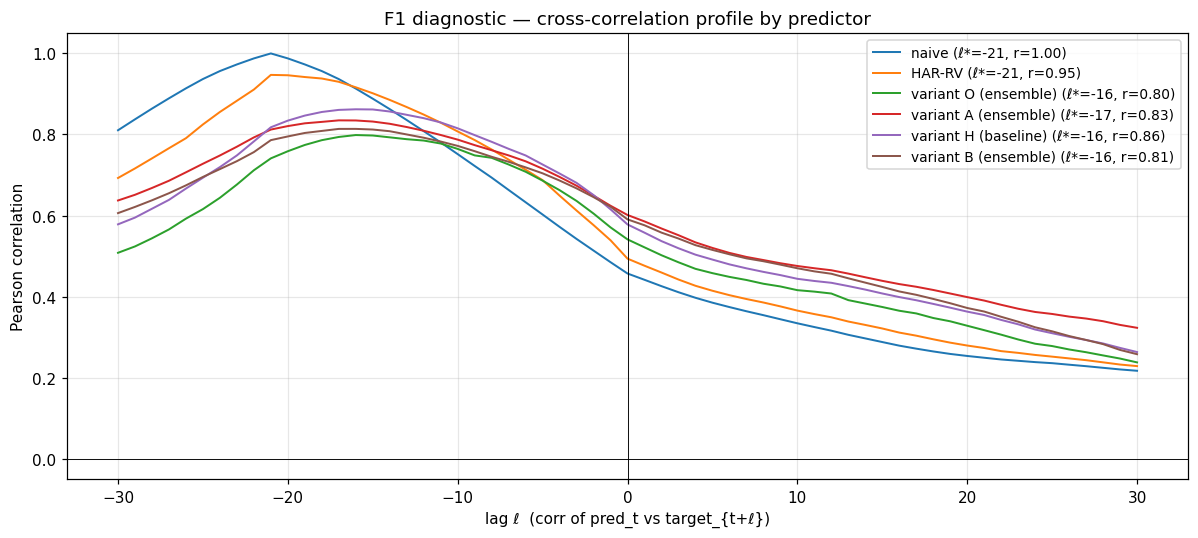


Peak cross-correlation summary:


,peak_lag,peak_corr,lag0_corr
predictor,,,
naive,-21,1.000,0.457
HAR-RV,-21,0.947,0.494
variant O (ensemble),-16,0.799,0.541
variant A (ensemble),-17,0.835,0.601
variant H (baseline),-16,0.862,0.578
variant B (ensemble),-16,0.814,0.590


In [9]:
def cross_correlation_lag_profile(pred, target, max_lag=30):
    pred = np.asarray(pred, float); target = np.asarray(target, float)
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for L in lags:
        if L < 0:   p, t = pred[-L:], target[:L] if L else target
        elif L > 0: p, t = pred[:-L], target[L:]
        else:       p, t = pred, target
        corrs.append(np.corrcoef(p, t)[0, 1] if len(p) > 2 else np.nan)
    return lags, np.array(corrs)


fig, ax = plt.subplots(figsize=(11, 5))
peaks = []
for name, pred in predictors.items():
    lags, corrs = cross_correlation_lag_profile(pred, y_true)
    peak_lag = int(lags[np.nanargmax(corrs)])
    peak_corr = float(np.nanmax(corrs))
    lag0_corr = float(corrs[lags == 0][0])
    peaks.append({"predictor": name, "peak_lag": peak_lag,
                  "peak_corr": round(peak_corr, 3), "lag0_corr": round(lag0_corr, 3)})
    ax.plot(lags, corrs, label=f"{name} (ℓ*={peak_lag}, r={peak_corr:.2f})", linewidth=1.3)

ax.axvline(0, color="black", lw=0.6); ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("lag ℓ  (corr of pred_t vs target_{t+ℓ})")
ax.set_ylabel("Pearson correlation")
ax.set_title("F1 diagnostic — cross-correlation profile by predictor")
ax.legend(fontsize=9, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout()

# Save the F1 figure for the paper (supplementary/figures/)
figures_dir = REPO_ROOT / "supplementary" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = figures_dir / "F1_cross_correlation_profile.pdf"
plt.savefig(fig_path, bbox_inches="tight")
print(f"Saved F1 figure → {fig_path.relative_to(REPO_ROOT)}")

plt.show()

print("\nPeak cross-correlation summary:")
pd.DataFrame(peaks).set_index("predictor")


## 7. F2 diagnostic — prediction std per regime-LSTM

F2 predicts the volatile-regime LSTM output collapses toward a constant (near-mean of its ~180 training targets) because the regime-filtered training set is too small. This cell reports `(mean, std, range)` of predictions for every LSTM — within each ensemble variant, the volatile LSTM should have dramatically lower `std` than baseline or calm.

HAR-RV is included as a single OLS row for reference.


In [10]:
f2_rows = []
tgt_std = float(np.std(y_true))

# Per-seed F2: load from seeds/ so we can see per-seed failure modes.
# F2's seed-dependent pathology (constant vs wild volatile LSTM output) is itself
# paper-relevant — see discussion.md 2026-04-23 late-late evening.
SEEDS = [42, 43, 44]
SEEDS_DIR = DATA_PROCESSED / "seeds"

for variant_name, base_suffix in [("O", "_O"), ("A", ""), ("B", "_B")]:
    for seed in SEEDS:
        p = SEEDS_DIR / f"test_predictions{base_suffix}_seed{seed}.parquet"
        if not p.exists():
            continue
        df = pd.read_parquet(p).reindex(common).dropna()
        for model in ["baseline", "calm", "volatile", "ensemble"]:
            arr = df[model].values
            f2_rows.append({
                "variant": variant_name, "seed": seed, "component": model,
                "pred_std":   round(float(arr.std()),   6),
                "pred_range": round(float(arr.max() - arr.min()), 6),
                "ratio_vs_target_std": round(float(arr.std()) / tgt_std, 3) if tgt_std else None,
            })

# Variant H across seeds (single-LSTM, no regimes)
for seed in SEEDS:
    p = SEEDS_DIR / f"test_predictions_H_seed{seed}.parquet"
    if not p.exists():
        continue
    df = pd.read_parquet(p).reindex(common).dropna()
    arr = df["baseline"].values
    f2_rows.append({
        "variant": "H", "seed": seed, "component": "baseline",
        "pred_std": round(float(arr.std()), 6),
        "pred_range": round(float(arr.max() - arr.min()), 6),
        "ratio_vs_target_std": round(float(arr.std()) / tgt_std, 3) if tgt_std else None,
    })

# HAR-RV (deterministic OLS — single row, no seed column)
arr = pred_HAR["har_rv"].values
f2_rows.append({
    "variant": "HAR-RV", "seed": "-", "component": "ols",
    "pred_std": round(float(arr.std()), 6),
    "pred_range": round(float(arr.max() - arr.min()), 6),
    "ratio_vs_target_std": round(float(arr.std()) / tgt_std, 3) if tgt_std else None,
})

print(f"Target std on common index: {round(tgt_std, 6)}")
print("A component's `pred_std` << target std indicates the LSTM collapsed to near-constant output (F2).")
print()

if f2_rows:
    f2_df = pd.DataFrame(f2_rows).set_index(["variant", "seed", "component"])
    display(f2_df)
else:
    print("No per-seed parquets found under data/processed/seeds/. Run nb 06 first.")


Target std on common index: 0.004414
A component's `pred_std` << target std indicates the LSTM collapsed to near-constant output (F2).



pred_std  pred_range  ratio_vs_target_std
variant seed component                                           
O       42   baseline   0.003519    0.024068                0.797
             calm       0.032895    0.906100                7.452
             volatile   0.003118    0.025239                0.706
             ensemble   0.002861    0.025205                0.648
        43   baseline   0.000000    0.000000                0.000
             calm       0.055541    1.384108               12.582
             volatile   0.003165    0.020846                0.717
             ensemble   0.002985    0.020823                0.676
        44   baseline   0.003359    0.021262                0.761
             calm       0.059663    1.208827               13.516
             volatile   0.003782    0.026917                0.857
             ensemble   0.003631    0.043338                0.823
A       42   baseline   0.003545    0.018148                0.803
             calm       0.003281    0.027741                0.743
             volatile   0.731705    2.723479              165.760
             ensemble   0.003069    0.015793                0.695
        43   baseline   0.003899    0.025265                0.883
             calm       0.003649    0.039201                0.827
             volatile   0.258878    2.143404               58.646
             ensemble   0.003398    0.019406                0.770
        44   baseline   0.004938    0.031404                1.119
             calm       0.003473    0.031099                0.787
             volatile   0.858610    2.781348              194.509
             ensemble   0.003250    0.016491                0.736
B       42   baseline   0.002040    0.019388                0.462
             calm       0.003024    0.038918                0.685
             volatile   0.055572    0.436817               12.589
             ensemble   0.002495    0.018197                0.565
        43   baseline   0.004031    0.030787                0.913
             calm       0.003798    0.054858                0.860
             volatile   0.000423    0.001292                0.096
             ensemble   0.002715    0.014339                0.615
        44   baseline   0.002892    0.036671                0.655
             calm       0.003444    0.054628                0.780
             volatile   0.006831    0.033528                1.548
             ensemble   0.002789    0.017902                0.632
H       42   baseline   0.003081    0.030513                0.698
        43   baseline   0.003514    0.029591                0.796
        44   baseline   0.003277    0.026419                0.742
HAR-RV  -    ols        0.003324    0.030390                0.753

## 8. Summary — paper-quotable claims

Fill in the blanks from the tables above once the notebook has run on real artifacts.

### Headline — research question answer

The central question (*"does per-regime LSTM training help over a base LSTM at predicting 21-day-forward volatility?"*) is answered by the within-variant DM tests in **nb 06 §4**, not here. This notebook's role is to provide the cross-variant context (HAR-RV as econometric reference, F1 + F2 as structural diagnostics, 15 pairwise comparisons to situate each variant relative to the others).

### Defensible claims (scaffolded)

Write the actual values in place of `X`, `Y`, etc. once the tables render.

1. **vs naive:**
   - *"All learned variants (O / A / H / B) and the HAR-RV benchmark significantly outperform the naive rolling-std-21 persistence baseline on MAE (BH-FDR p < 0.05)."* — expected; sanity check.
   - If any variant fails this: *"Variant X ties with naive on MAE, consistent with the variant reducing to pure persistence at h = 21."*

2. **vs HAR-RV:**
   - *"Variants A / B ensemble [significantly beat / tie with] HAR-RV on MSE (DM p = X, BH-FDR p = Y)."* This decides whether the deep regime-split model adds value over the 3-parameter OLS.
   - If ties: *"A 3-feature OLS matches a 17k-parameter regime-split ensemble at h = 21, consistent with the structural-limits framing (F1)."* — strongest possible paper story.

3. **Regime-split value (from nb 06 §4):**
   - *"Within-variant DM tests show regime-split ensembles are [significant / tied] with their single-LSTM baselines on {O / A / B} (p = X / Y / Z, BH-FDR)."* Quote the nb 06 result here for the reader's convenience.

4. **Feature-richness comparisons:**
   - *"Adding AAII sentiment (O → A) [helps by X% MSE / does not help] (DM p = Y)."*
   - *"Adding VIX family (A → B) [helps by X% MSE / does not help] (DM p = Y)."*
   - *"Adding regime posterior as LSTM feature (A → H) [helps / hurts / is neutral] (DM p = Y)."*

5. **F1 (shift-lag):**
   - *"Peak cross-correlation lag across all 6 predictors ranges from ℓ = X to ℓ = Y (all negative). No variant pulls the peak toward ℓ = 0 — consistent with the persistence-shift floor being a property of the daily-frequency × 21-day-forward target, not of the feature set or architecture."*

6. **F2 (volatile-LSTM degeneracy):**
   - *"Variant {O / A / B}'s volatile LSTM has prediction std = X, vs the target std = Y — prediction std is {Z}× smaller, indicating near-constant output. Consistent with F4 (data scarcity: ~180 volatile-majority training windows for the regime LSTMs)."*

### Limitations to acknowledge

- **Single-seed results** — each LSTM was trained with one seed. Per `supplementary/discussion.md`, the ensemble MSE swung ~+53 % between identical-config reruns. Point estimates should be interpreted with caution; ranking claims are supported by the DM tests' structural-invariance across variants.
- **Aggregate multicollinearity** — several HMM / LSTM feature sets have VIF > 10 (see nb 01 § 7b). No pairs exceed 0.95 correlation. Handled by StandardScaler + HMM `reg_covar`; does not break the pipeline.
- **Training-window asymmetry** — variant B trains on ~1,680 fewer rows than O / A (VIX3M history starts 2007-12).  Paper discloses this.
